In [2]:
# Importing libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [1]:
import seaborn as sns

In [4]:
# Only get data analyst jobs in the US
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

# Drop NA values in salary_year_avg column for accurate visualization
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

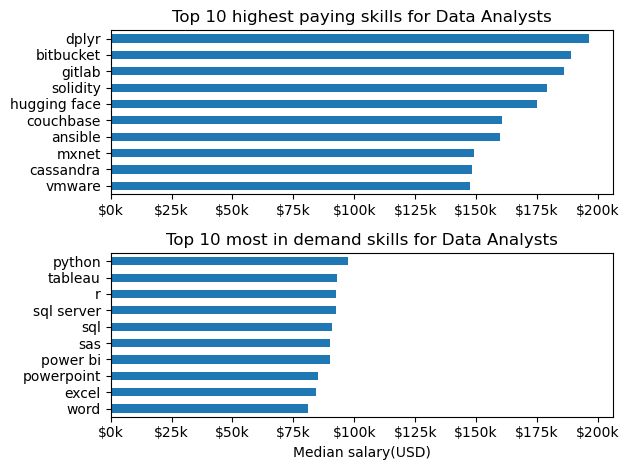

In [5]:
df_DA_US = df_DA_US.explode('job_skills')
df_DA_US_group = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])

df_DA_top_pay = df_DA_US_group.sort_values('median', ascending=False).head(10)

df_DA_skills = df_DA_US_group.sort_values('count', ascending=False).head(10).sort_values('median', ascending=False).head(10)
fig, ax = plt.subplots(2, 1)

#Top 10 highest paying skills for Data Analysts
df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].set_title('Top 10 highest paying skills for Data Analysts')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))

#Top 10 most in demand skills for Data Analysts
df_DA_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('Top 10 most in demand skills for Data Analysts')
ax[1].set_xlabel('Median salary(USD)')
ax[1].set_ylabel('')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))

fig.tight_layout()
plt.show()

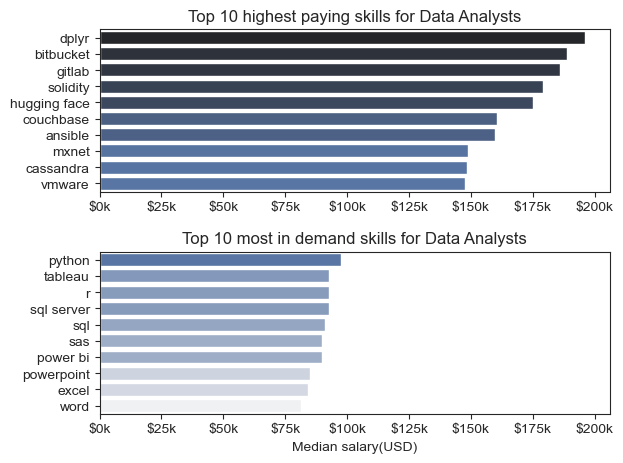

In [15]:
df_DA_US = df_DA_US.explode('job_skills')
df_DA_US_group = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])

df_DA_top_pay = df_DA_US_group.sort_values('median', ascending=False).head(10)

df_DA_skills = df_DA_US_group.sort_values('count', ascending=False).head(10).sort_values('median', ascending=False).head(10)
fig, ax = plt.subplots(2, 1)
sns.set_theme(style='ticks')

#Top 10 highest paying skills for Data Analysts

sns.barplot(data=df_DA_top_pay, x='median', y=df_DA_top_pay.index, ax=ax[0], hue= 'median', palette='dark:b_r')
ax[0].legend_.remove()
#df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].set_title('Top 10 highest paying skills for Data Analysts')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))

#Top 10 most in demand skills for Data Analysts

sns.barplot(data=df_DA_skills, x='median', y=df_DA_skills.index, ax=ax[1], hue= 'median', palette='light:b')
ax[1].legend_.remove()
#df_DA_skills[::-1].plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_title('Top 10 most in demand skills for Data Analysts')
ax[1].set_xlabel('Median salary(USD)')
ax[1].set_ylabel('')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))

fig.tight_layout()
plt.show()

Text(0, 0.5, 'Number of jobs')

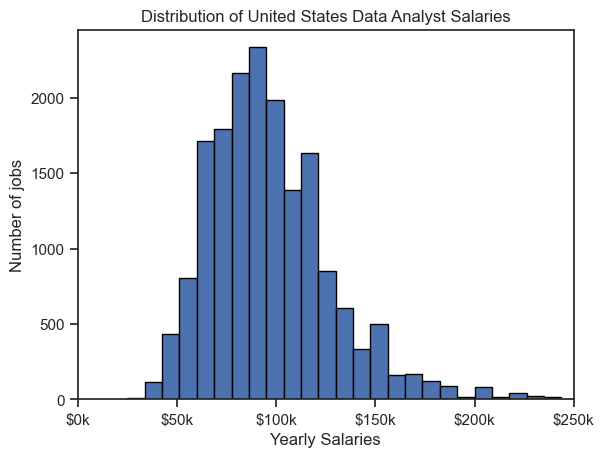

In [16]:
df_DA_US['salary_year_avg'].plot(kind= 'hist', bins= 40, edgecolor= 'black')
plt.xlim(0, 250000)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
plt.title('Distribution of United States Data Analyst Salaries')
plt.xlabel('Yearly Salaries')
plt.ylabel('Number of jobs')

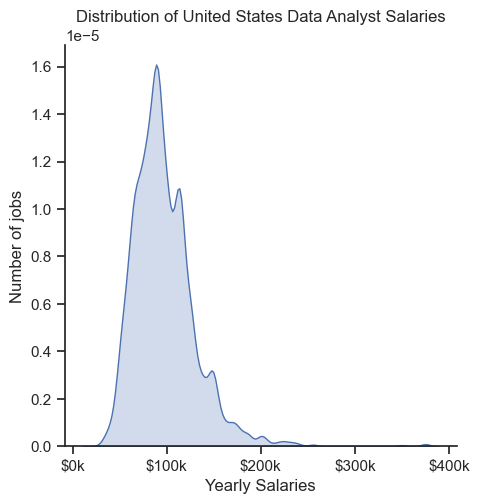

In [17]:
sns.displot(df_DA_US['salary_year_avg'], kind= 'kde', fill=True)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
plt.title('Distribution of United States Data Analyst Salaries')
plt.xlabel('Yearly Salaries')
plt.ylabel('Number of jobs')
plt.show()

C:\Users\Souradeep\AppData\Local\Temp\ipykernel_14720\4237257076.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_lists, labels = job_titles, vert=False)


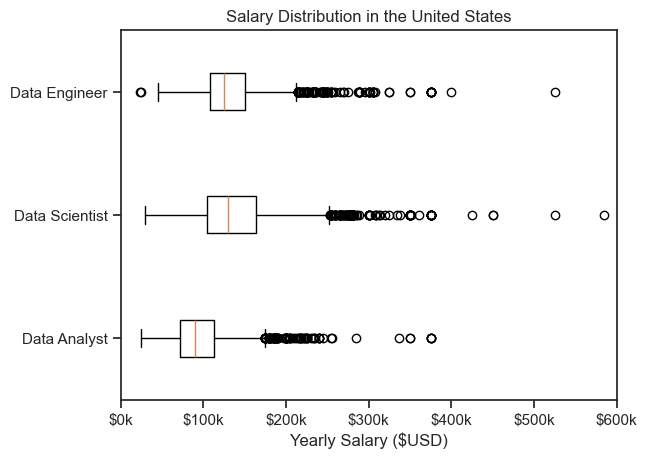

In [18]:
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

df_US =  df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()
df_US = df_US.dropna(subset=['salary_year_avg'])

job_lists = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]
plt.boxplot(job_lists, labels = job_titles, vert=False) 
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))
plt.xlim(0, 600000)
plt.show()

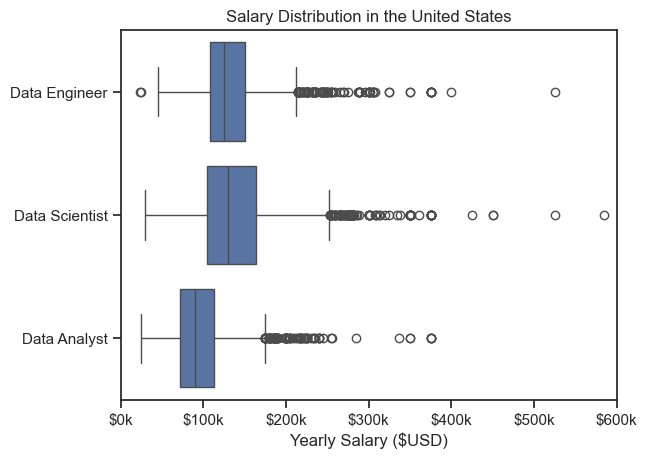

In [21]:
sns.boxplot(data=df_US, x='salary_year_avg', y='job_title_short')
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')
plt.ylabel('')
ax = plt.gca()
ticks_x = plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}k')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.xlim(0, 600000)
plt.show()